In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# CA-024-01-value-within-groups

Theory **CA-024**. The battery's verdict: the strategy stops at gate 2, economic edge: Sharpe 0.579 against the benchmark's 0.644, alpha -0.63%; at twice the costs, Sharpe 0.572 and alpha -0.73%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Investors overreact and extrapolate, and arbitrage capital is slow and constrained, so that within a group of comparable assets the members whose prices fell most over several years are cheap and those that rose most are dear, and prices revert: the cheap members of each group outperform the dear ones over the following years, in each group, with a common structure across the groups and a return opposed to momentum's.

**Prediction.** sign: positive, size: an alpha of about 0.7 to 1.5% a year over the same funds held in equal parts, an appraisal ratio of about 0.12 to 0.25; built group by group from the study's long-short value premia (about 5.8% a year in commodities, 3.5% in stock selection), four fifths of that for the price-only measure on equities, 40 to 50% of it long only, at CA-001-01's tracking error of about 6% a year on the same groups; from half to all of the long record, which the 2010s in several asset classes point below

**What would refute it.** Judged on the base by its alpha over the same funds held in equal parts, as gate 2 measures it, and by the share of its placebos, shifted in time, that it beats at the lab's costs. The theory is refuted in this form if the alpha is zero or less and the base beats half of its placebos or fewer: the cheapest members of the groups would then have earned no more than the groups from 2010 to 2022, as the bank's first refutation reads for these asset classes. Any other result short of passing gates 1 to 7 is not proven, not refuted. Reported, not graded: the variants, the three-year window and the year skipped; the value tilt's alpha in each group, with a beta for each; the correlation of the tilt's hedged monthly returns between the groups, and with CA-001-01's momentum tilt over the same months; the alpha by year, and in 2020.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, SPY, QQQ, IWM, EFA, EEM, GLD, SLV, DBC. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2010-02-01, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

On the first session of each month, within each of three groups -- the eleven sector funds; the five equity markets SPY, QQQ, IWM, EFA and EEM; the commodities GLD, SLV and DBC -- the members are ranked by their return from lookback sessions before the session before the target to skip sessions before that session before. The bottom third of each group's ranked members, rounded, one at least, is held: the cheapest by their price then against their price now. Of the N assets trading, a group of n ranked members holds n/N of the portfolio, split equally among its cheapest; an asset trading without lookback sessions of prices is not ranked and is held at 1/N, its benchmark weight. The targets start on the first month in which an asset is ranked; from then the portfolio is always fully invested.

- **lookback**: sessions from the start of the value window to the session before the target
- **skip**: sessions before the session before the target left out of the value window

,lookback,skip
base,1260,0
variant 1,756,0
variant 2,1260,252


Parameter neighbours, moved one at a time for gate 6: lookback at ±25%: 945, 1575; lookback at ±50%: 630, 1890.

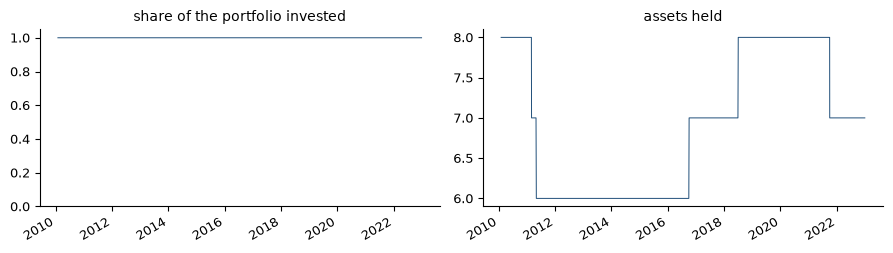

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

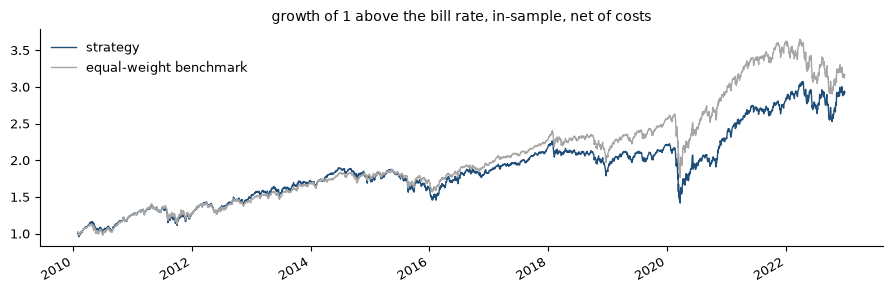

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 300 dates, 70 decisions over 12.9 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,300,0,0,1260,150,0,none,70,12.91,5


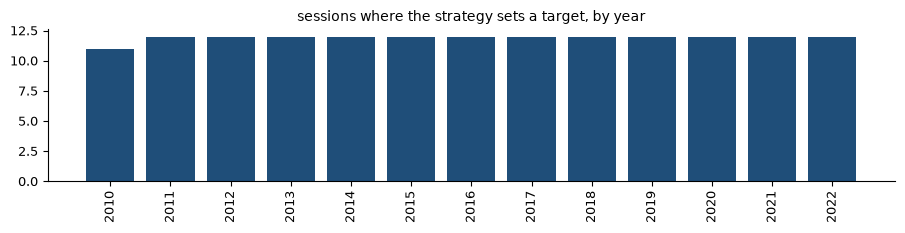

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Fails**: Sharpe 0.579 against the benchmark's 0.644, alpha -0.63%; at twice the costs, Sharpe 0.572 and alpha -0.73%.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.5791,0.644,-0.006295,0.5718,-0.007334,0.5864,0.001226,0.007297


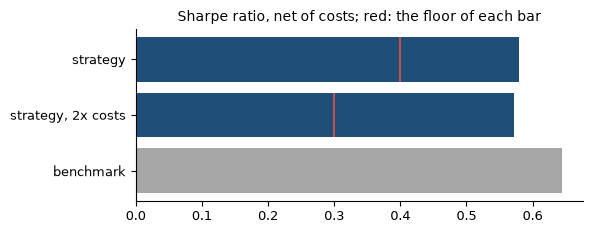

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Passes**: PSR 0.986, beats 92% of 1000 shifted placebos.

,PSR,placebo sessions,placebos,placebos beaten
,0.9865,3253,1000,0.924


Assets that start trading after 2010-02-01: XLC, XLRE. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

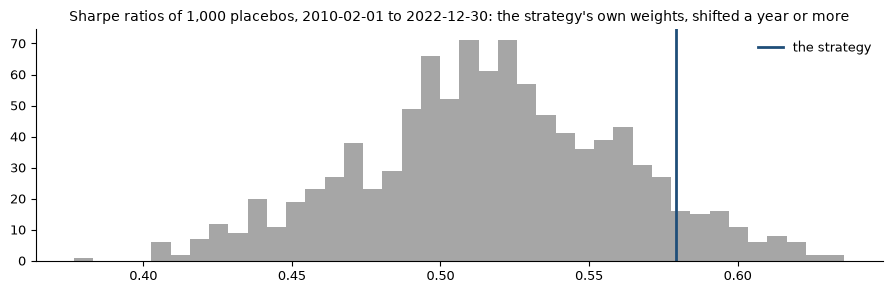

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.006 below 0.9 over 28 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,31,28,-0.1296,0.5691,0.005974


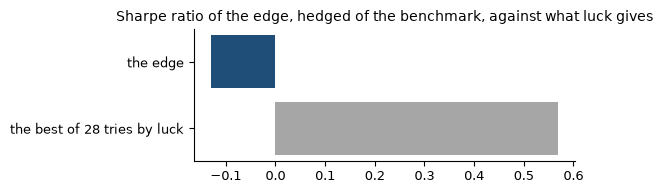

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 2 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -2.30% without its best year, 2022.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,False,True,False,0.5512,1,2022,-0.02297


The blend of the variants: gate 2, Sharpe 0.584 against the benchmark's 0.644, alpha -0.65%; at twice the costs, Sharpe 0.575 and alpha -0.77%; gate 4, DSR 0.005 below 0.9 over 28 effective trials.

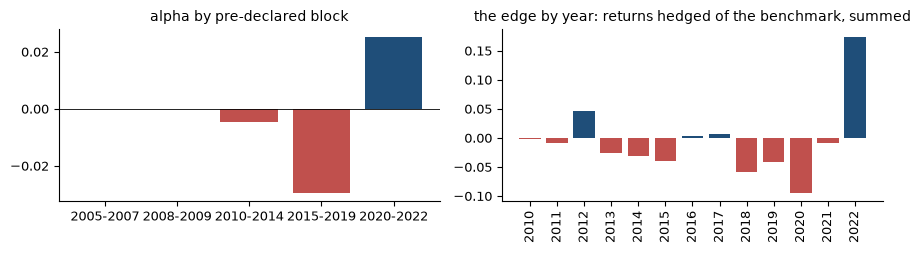

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9921,0.7154,none,sectors,0.5428,0.228,XLE,0.9832,—,—


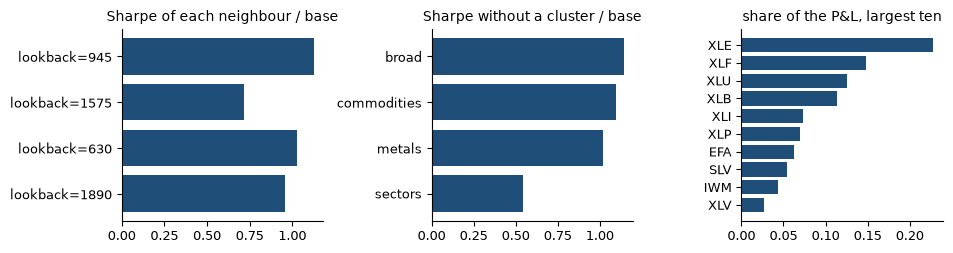

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 1.07 and alpha 1.43%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,1.073,-0.1396,0.01429,-0.04917,0,60,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

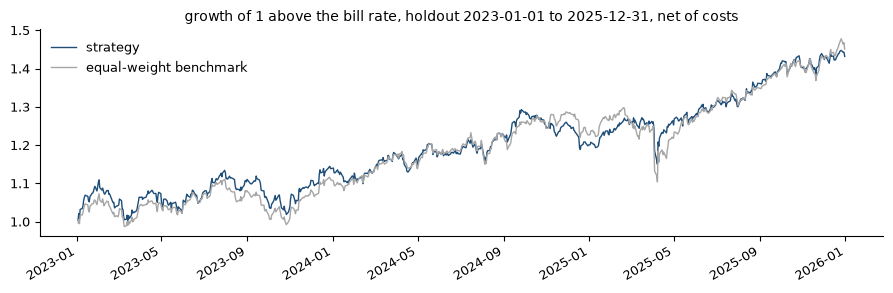

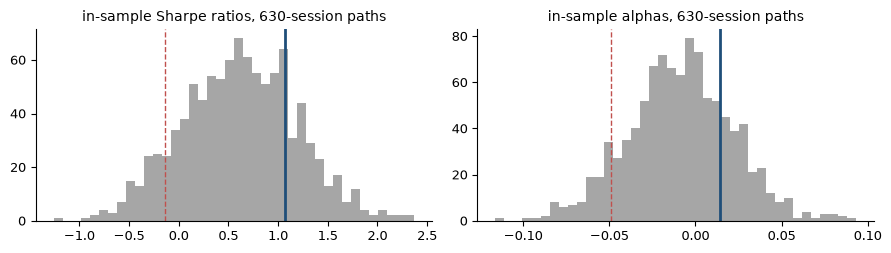

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 300 dates, 70 decisions over 12.9 years"
2 · Economic edge,fails,"Sharpe 0.579 against the benchmark's 0.644, alpha -0.63%; at twice the costs, Sharpe 0.572 and alpha -0.73%"
3 · Significance,passes,"PSR 0.986, beats 92% of 1000 shifted placebos"
4 · Multiple testing,fails,DSR 0.006 below 0.9 over 28 effective trials
5 · Stability,fails,"the blend of the variants fails gates 2 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -2.30% without its best year, 2022"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 1.07 and alpha 1.43%, both above the in-sample 10th percentile"


Thresholds, version 3. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).